# 🎓 Predicting Student Mental Health Score from Social Media Usage
**Problem** : We're predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

**Dataset** : Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

## 1. Import Libraries
We're grouping imports by purpose: data handling, visualization, preprocessing, models, evaluation, and saving. Keeping imports grouped like this makes it easy to see at a glance what the notebook is going to do.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Load the Dataset
We load the CSV and take a first look at its shape and the first few rows. This is always the very first step — we can't make any decisions about a dataset until we've actually looked at it.

In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [3]:
#Looking for first five rows.
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
#Looking for no of rows and columns
df.shape

(5000, 13)

In [5]:
#Looking for datatypes of columns 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [7]:
#check for null values -
null = df.isnull().sum()
print(null)

if null.sum() == 0:
    print("-"*30)
    print(f"No Null Values in dataframe")

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64
------------------------------
No Null Values in dataframe


In [8]:
# check for duplicates 
df.duplicated().sum()

np.int64(2)

**Reading this** : Most columns look reasonable — but look closely at Physical_Activity_Hours: the minimum value is -0.4. Negative hours aren't physically possibles so, we'll fix this properly in the Data Cleaning step.

## 3. Exploratory Data Analysis (EDA)
We'll keep this focused — six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

#### 3.1 — Distribution of the target (Mental_Health_Score)

In [9]:
colm = ['Mental_Health_Score']
summary = df[colm].describe().T
summary['median'] = df[colm].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['Skewness'] = df[colm].skew()

summary

,count,mean,std,min,25%,50%,75%,max,median,IQR,Skewness
Mental_Health_Score,5000.0,6.23098,1.278701,3.6,5.1,6.1,7.1,9.4,6.1,2.0,0.206567


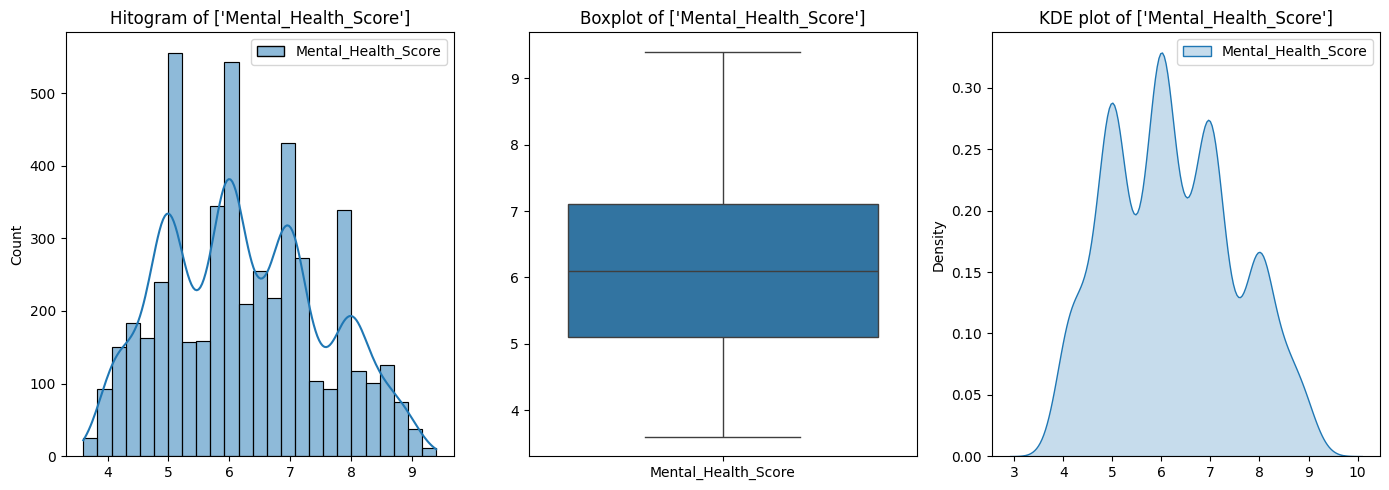

In [10]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
sns.histplot(df[colm],kde=True)
plt.title(f'Hitogram of {colm}')

plt.subplot(1,3,2)
sns.boxplot(df[colm])
plt.title(f'Boxplot of {colm}')

plt.subplot(1,3,3)
sns.kdeplot(df[colm], fill=True)
plt.title(f'KDE plot of {colm}')

plt.tight_layout()
plt.show()

### 3.2 — Correlation heatmap
Which numeric features actually move together with the target?

<Axes: >

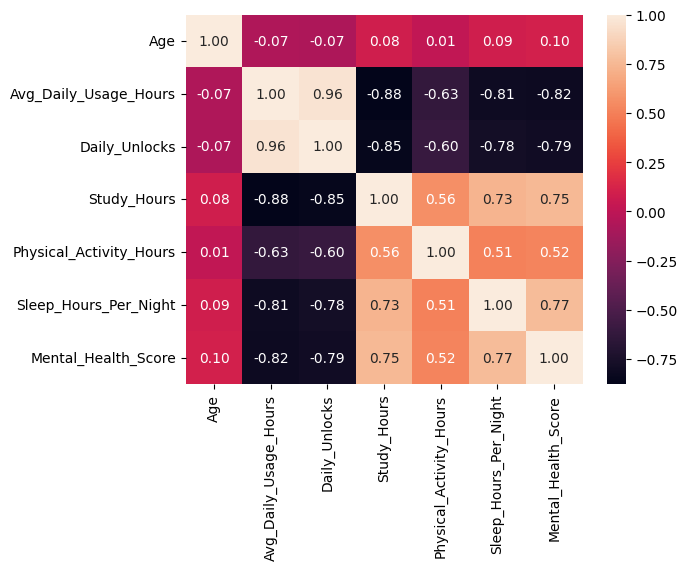

In [11]:
num_colms = df.select_dtypes(include='number')
corr = num_colms.corr()

sns.heatmap(
    corr, 
    annot=True, 
    fmt='.2f'
)

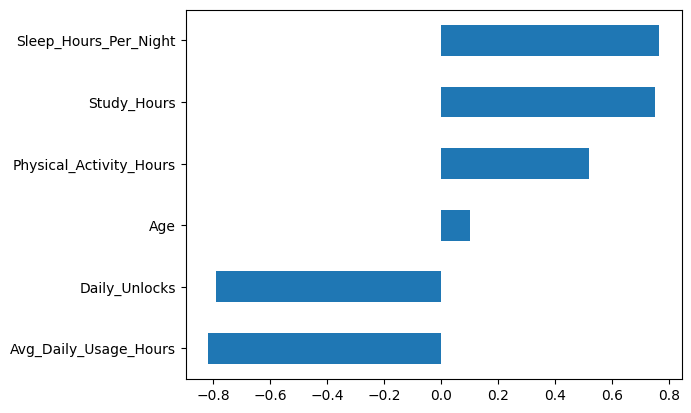

In [12]:
corr1 = corr['Mental_Health_Score'].drop('Mental_Health_Score')
corr1.sort_values().plot(kind='barh')

plt.show()

### 3.3 — Stress Level vs Mental Health Score
Does higher stress genuinely come with a lower score?

In [13]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

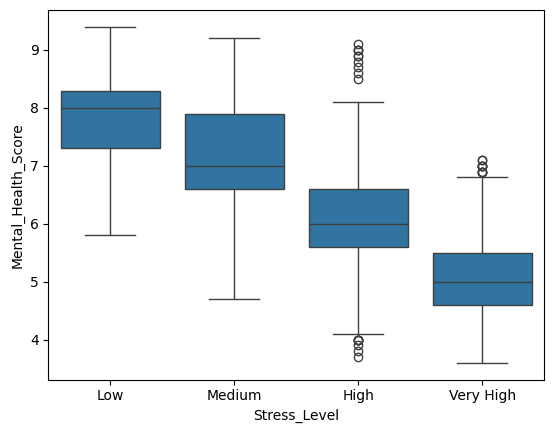

In [14]:
order = ['Low','Medium','High','Very High']
sns.boxplot(data=df, x= df['Stress_Level'], y= df['Mental_Health_Score'], order= order)

### 3.4 — Daily Usage Hours vs Mental Health Score
Does more time on social media relate to a lower score?

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

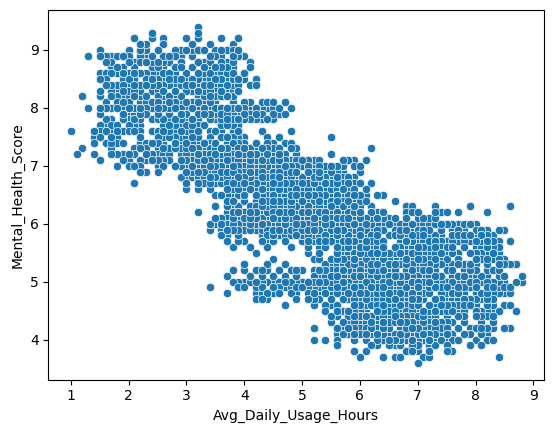

In [15]:
sns.scatterplot(data=df,x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])

### 4.5 — Sleep Hours vs Mental Health Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

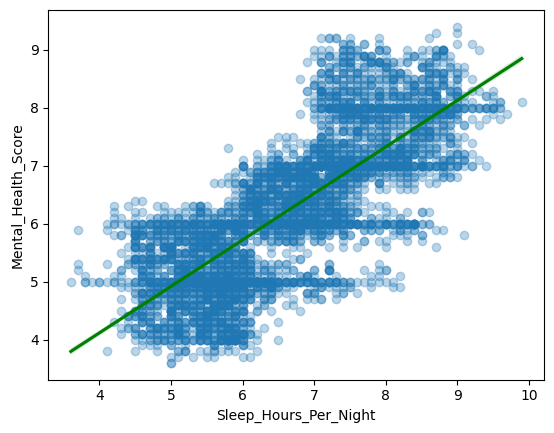

In [16]:
sns.regplot(data=df,x=df['Sleep_Hours_Per_Night'],
            y=df['Mental_Health_Score'],
            scatter_kws={'alpha': 0.3}, 
            line_kws={'color': 'green'})

### 3.6 — Most Used Platform (count)

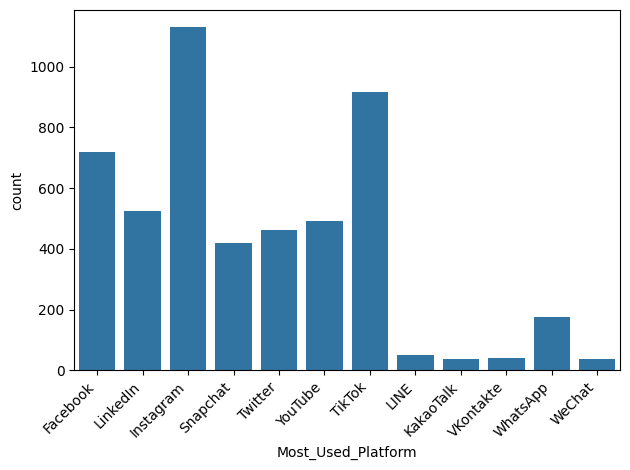

In [17]:
sns.countplot(data=df,x=df["Most_Used_Platform"])

plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

### **Checking Outliers**

In [18]:
Q1 = num_colms.quantile(0.25)
Q3 = num_colms.quantile(0.75)

IQR = Q3-Q1 

lower_fence = Q1-1.5*IQR

upper_fence = Q3+1.5*IQR

outliers = (num_colms<lower_fence) | (num_colms>upper_fence)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## 4. Data Cleaning

In [19]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [20]:
#1. Drop Duplicates 

df = df.drop_duplicates()

#2. Converting negative values or unrealistic values to realistic value

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [21]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## 5. Skewness

In [22]:
num_colms.skew()

Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.039971
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

## 6. Feature Engineering

Country has 111 unique values in this dataset.
The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [23]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [24]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [25]:
df['Grouped_country'] = df['Country'].apply(group_countries)
df['Grouped_country'].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

Result: we went from 111 raw categories down to 10 manageable ones. This is exactly the kind of decision that separates a project that "just ran pd.get_dummies()" from one that actually thought about the data.

## 7. Train-Test Split

In [26]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [27]:
from sklearn.model_selection import train_test_split

skewed_colm = ['Study_Hours']
other_num_colm = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_colm = ['Stress_Level']
normal_colm = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

feature_colms = skewed_colm + other_num_colm + ordinal_colm + normal_colm

X = df[feature_colms]
y = df['Mental_Health_Score']

X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [28]:
print('x_train shape--',X_train.shape)
print('x_test shape--',X_test.shape)
print('y_train shape--',y_train.shape)
print('y_test shape--',y_test.shape)

x_train shape-- (3998, 12)
x_test shape-- (1000, 12)
y_train shape-- (3998,)
y_test shape-- (1000,)


## 8. Preprocessing using ColumnTransformer

Our columns need different treatment:
- Study_Hours (the skewed one) → impute → log1p transform → scale
- The other numeric columns → impute → scale (no skew to fix)
- Stress_Level → impute → OrdinalEncoder with an explicit order
- The nominal columns → impute → OneHotEncoder

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer , StandardScaler , OrdinalEncoder , OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Skewed feature 
skew_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)), 
    ('scale',StandardScaler())
])


# 2. Numeric features
num_pipeline = Pipeline(steps=[
    ('scaling',StandardScaler())
])

# 3. Ordinal 
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# 4. Nominal
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ('Skewed_Pipeline',skew_pipeline,skewed_colm), 
    ('Num_Pipeline',num_pipeline,other_num_colm), 
    ('Ordinal_pipeline',ordinal_pipeline,ordinal_colm),
    ('Nominal_pipeline',nominal_pipeline,normal_colm)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skewed_Pipeline', ...), ('Num_Pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

## 9. Model Building

### 9.1 — Baseline: Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7255672449830839
Accuracy of Testing 0.7428129069013331
MAE 0.5338894857575271


## 9.2 — Random Forest (default settings)

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor), 
    ('model',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_score = r2_score(y_test,rf_preds)
rf_r2_score_train = r2_score(y_train,rf_preds_train)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_score_train}")
print(f"Accuracy of Testing {rf_r2_score}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9827094985154842
Accuracy of Testing 0.8901510306606107
MAE : 0.326722280952381


### 9.3 — Hyperparameter Tuning the Random Forest

In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [5,10,15],
    'model__min_samples_split': [2,5,10],
    'model__min_samples_leaf': [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [40]:
random_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 2,
 'model__max_depth': 15}

In [41]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.874648013442844
MAE Score for random forest after hyperparameter tuning 0.3545837193560476


## 10. Model Evaluation

In [46]:
# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_preds))

# Calculate RMSE for default Random Forest 
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = rf_best_pipeline.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = rf_best_pipeline.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)



# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_score, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_score_train, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.742813     0.725567  0.533889  0.677593
1  Random Forest (default)  0.890151     0.982709  0.326722  0.442835
2    Random Forest (tuned)  0.874648     0.956186  0.354584  0.473053


## 11. Save the Model

In [48]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']